# 层次分析法（AHP）完整流程与代码实现

> **评价类模型——层次分析法 AHP 整理笔记**
> 本笔记覆盖 AHP 完整流程、数学公式与配套代码实例；代码风格参考《代码基础》讲义。


# 二、AHP 基本流程总览

层次分析法的完整流程可以概括为 **四大步骤**，每一步环环相扣：

> - **建立层次结构**：把问题分解成问题（目标层）、准则（准则层）、方案（方案层）（画图表示）
> - **构造判断矩阵**：对同一层元素进行两两比较，给出相对重要性标度
> - **计算权重与检验**：从矩阵中得到各元素的权重（表示不同指标的重要程度），并进行一致性检验（**先检验后排序**）
> - **层次总排序**：将各层权重逐级合成，得到方案对总目标的最终排序

## 各步骤的核心任务与输出

| 步骤 | 核心任务 | 主要输入 | 主要输出 | 涉及的关键算法 |
|------|---------|---------|---------|---------------|
| ① 建立层次结构 | 把复杂问题分解为有序的层次 | 问题描述 | 层次结构图（目标层/准则层/方案层） | 问题分解、MECE 原则 |
| ② 构造判断矩阵 | 对同层元素两两比较打分 | 专家经验（Saaty 1~9 标度） | 判断矩阵 $A=(a_{ij})_{n\times n}$ | 成对比较法 |
| ③ 计算权重与检验 | 从矩阵提取权重，并检验判断逻辑是否一致 | 判断矩阵 $A$ | 权重向量 $w$、$\lambda_{max}$、CI、CR | 特征值法、一致性检验 |
| ④ 层次总排序 | 各层权重逐级合成，得到方案最终排序 | 各层权重、方案层数据 | 方案综合得分与排序 | 加权求和（或逐级合成） |

## 完整流程图（文字版）

```
┌─────────────────────────────────────────────────────────┐
│  开始：明确评价目标                                          │
├─────────────────────────────────────────────────────────┤
│  ① 建立层次结构：目标层 → 准则层（→ 子准则层）→ 方案层       │
├─────────────────────────────────────────────────────────┤
│  ② 构造判断矩阵：对每个准则下的元素两两比较（1~9 标度）      │
├─────────────────────────────────────────────────────────┤
│  ③ 计算权重与检验                                          │
│     ├─ 计算权重 w（特征向量法 / 算术平均法 / 几何平均法）     │
│     ├─ 计算 λmax → CI → 查 RI → CR                        │
│     └─ CR < 0.10 ？ ──否──▶ 修正判断矩阵，重新比较          │
│                 │是                                         │
├─────────────────────────────────────────────────────────┤
│  ④ 层次总排序：全局权重 = 准则权重 × 局部权重，方案加权评分    │
├─────────────────────────────────────────────────────────┤
│  输出：方案排序结果 + 敏感性/稳健性分析（进阶）                │
└─────────────────────────────────────────────────────────┘
```

<span style="color:#c0392b">**⚠️ 核心原则：先检验、后排序。**</span> 只有通过一致性检验（$CR<0.10$）的判断矩阵，其权重才是可信的，才能进入下一步的合成与排序。下面各节将按照这四大步骤逐一展开，并配套给出数学公式与可运行的代码实例（案例：**城市社区应急避难场所选址**）。


# 准备工作：运行环境与演示案例

## 运行环境

- Python 3.9+，依赖库：`numpy`、`pandas`、`matplotlib`（如未安装请先 `pip install numpy pandas matplotlib`）
- 本 notebook 中的代码**自包含**，按顺序运行即可复现全部结果

## 演示案例（贯穿全文）

以案例 **"城市社区应急避难场所选址"** 为例：

> 某市拟新建一处综合型社区应急避难场所，规划部门初选了 **5 个候选点**（东湖公园、河滨体育场、新城广场、北站物流园、南郊校园），需从 **8 项指标**（分属 4 个准则）出发建立综合评价模型，对候选点排序并给出首选与备选方案。

- **准则层**：安全性、可达性、承载能力、经济与环境（4 个准则）
- **指标层**：每个准则下 2 项指标，共 8 项（安全评分、洪涝风险、疏散时间、医疗距离、可用面积、覆盖人口、建设成本、生态扰动）
- **方案层**：5 个候选点（有实测数据）

数据来源于配套的《候选点原始数据.csv》，本文给出的全部数值（权重、CR、排序）都可在本 notebook 中逐一复现验证。


In [19]:
# ============================================================
# 准备工作：导入库 + 案例数据
# 数据来源：《候选点原始数据.csv》
# （5 个候选点 × 8 项指标，城市社区应急避难场所选址问题）
# ============================================================

# 导入所需库。
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示与绘图参数。
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (9, 5)

# ---- 案例数据：5 个候选点 × 8 项指标 ----
# 指标顺序必须与后续判断矩阵的指标顺序保持一致。
names = ["东湖公园", "河滨体育场", "新城广场", "北站物流园", "南郊校园"]

indicators = [
    "地质与消防安全评分",     # 越大越好（收益型）
    "洪涝风险指数",           # 越小越好（成本型）
    "平均疏散时间_min",       # 越小越好（成本型）
    "最近医疗点距离_km",      # 越小越好（成本型）
    "可用面积_万m2",          # 越大越好（收益型）
    "服务覆盖人口_万人",      # 越大越好（收益型）
    "建设成本_百万元",        # 越小越好（成本型）
    "生态扰动指数",           # 越小越好（成本型）
]

# 指标类型：benefit = 收益型（越大越好），cost = 成本型（越小越好）。
indicator_types = {
    "地质与消防安全评分": "benefit",
    "洪涝风险指数": "cost",
    "平均疏散时间_min": "cost",
    "最近医疗点距离_km": "cost",
    "可用面积_万m2": "benefit",
    "服务覆盖人口_万人": "benefit",
    "建设成本_百万元": "cost",
    "生态扰动指数": "cost",
}

# 原始数据矩阵（行 = 候选点，列 = 指标）。
raw = np.array([
    [88, 0.18, 18, 2.4, 4.8, 7.2, 42, 0.22],   # 东湖公园
    [82, 0.32, 14, 1.2, 3.9, 8.5, 36, 0.35],   # 河滨体育场
    [90, 0.12, 16, 1.8, 3.2, 9.1, 48, 0.18],   # 新城广场
    [78, 0.20, 22, 3.0, 6.5, 6.0, 32, 0.48],   # 北站物流园
    [86, 0.15, 20, 0.9, 5.2, 6.8, 40, 0.15],   # 南郊校园
], dtype=float)

# 展示原始数据。
raw_df = pd.DataFrame(raw, index=names, columns=indicators)
print("=== 候选点原始数据（应急避难场所选址）===")
print(raw_df.to_string())


=== 候选点原始数据（应急避难场所选址）===
       地质与消防安全评分  洪涝风险指数  平均疏散时间_min  最近医疗点距离_km  可用面积_万m2  服务覆盖人口_万人  建设成本_百万元  生态扰动指数
东湖公园        88.0    0.18        18.0         2.4       4.8        7.2      42.0    0.22
河滨体育场       82.0    0.32        14.0         1.2       3.9        8.5      36.0    0.35
新城广场        90.0    0.12        16.0         1.8       3.2        9.1      48.0    0.18
北站物流园       78.0    0.20        22.0         3.0       6.5        6.0      32.0    0.48
南郊校园        86.0    0.15        20.0         0.9       5.2        6.8      40.0    0.15


# 三、步骤一：建立层次结构

## 1. 什么是层次结构

把复杂问题按"**目标 → 准则 → 方案**"逐层分解，上层元素支配下层元素，形成树状结构：

```
                    ┌─────────────────┐
                    │  目标层 G（1个）  │      ← 要解决的核心问题
                    └────────┬────────┘
          ┌──────────────────┼──────────────────┐
    ┌─────┴─────┐      ┌─────┴─────┐      ┌─────┴─────┐
    │ 准则 C1   │      │ 准则 C2   │  │    │ 准则 Cm   │   ← 评价的准则/指标（m 个）
    └─────┬─────┘      └─────┬─────┘      └─────┬─────┘
          └──────────┬───────┘                   │
              ┌──────┴──────┐                    │
        ┌─────┴─────┐  ┌────┴─────┐       ┌─────┴─────┐
        │ 方案 A1   │  │ 方案 A2  │  ...  │ 方案 An   │   ← 待评价/选择的方案（n 个）
        └───────────┘  └──────────┘       └───────────┘
```

- **目标层**：只有一个元素，即决策要解决的核心问题
- **准则层**：评价目标所需考虑的各项准则（可再细分为子准则层）
- **方案层**：待评价/选择的方案集合

## 2. 本案例的层次结构（应急避难场所选址）

- **目标层**：应急避难场所选址综合评价
- **准则层**（4 个）：安全性、可达性、承载能力、经济与环境
- **方案层**（5 个）：东湖公园、河滨体育场、新城广场、北站物流园、南郊校园

## 3. 构建原则与注意事项

<span style="color:#c0392b">**⚠️ 准则层元素一般不超过 9 个。**</span> 原因有二：
1. 两两比较次数为 $\binom{n}{2} = \frac{n(n-1)}{2}$，$n=9$ 时已达 36 次，$n$ 再大会导致专家打分负担过重；
2. 认知心理学研究表明人一次可稳定比较的对象为 **7±2** 个（Miller 定律）。

**其他构建要点**：
- 准则之间应**相互独立、含义清晰**，避免重叠（可借助 MECE 原则检查）
- 若准则过多，可增加**子准则层**（层次一般不超过 4 层）
- 方案层元素应**互斥且穷尽**（覆盖所有备选方案）
- 层次结构必须**先画图再建模**——层次结构图是 AHP 论文的必备插图


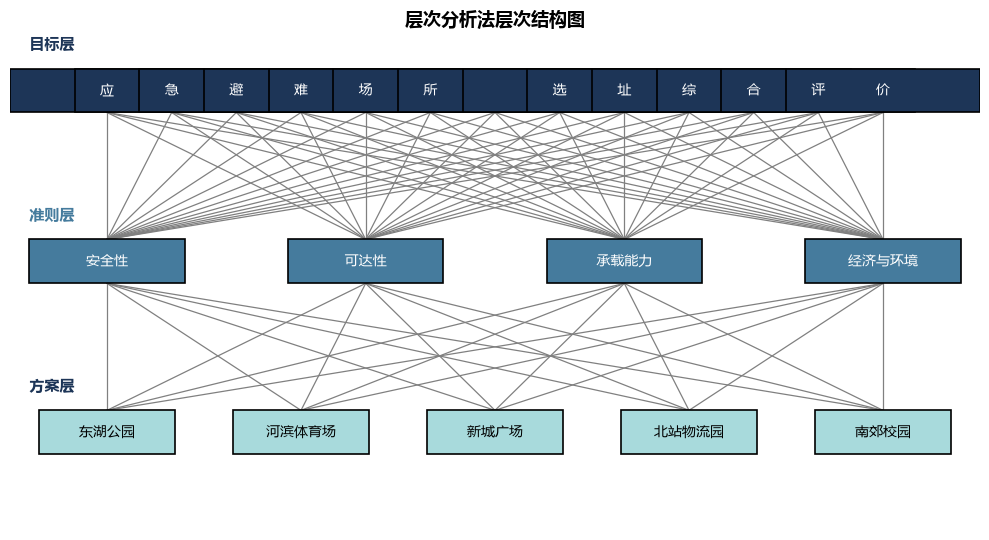

In [20]:
def draw_hierarchy(goal, criteria, alternatives, save_path=None):
    """绘制 AHP 层次结构图。

    布局：三层水平带，顶层 1 个目标框，中层准则框，底层方案框，
    相邻层之间用直线连接（上三角元素与下层全部元素相连）。
    """
    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    ax.axis("off")

    # 三个层次的 y 中心坐标（与 set_ylim(0,10) 匹配，确保画面分布均匀）。
    levels = [
        (goal, 9.0, "#1D3557", "white", 2.0),          # 目标层
        (criteria, 5.5, "#457B9D", "white", 1.6),      # 准则层
        (alternatives, 2.0, "#A8DADC", "black", 1.4),  # 方案层
    ]
    box_height = 0.9    # 矩形框高度

    # 1. 绘制三个层次的所有节点（矩形框）。
    boxes = []
    for items, y, facecolor, textcolor, width in levels:
        n = len(items)
        row = []
        for i, item in enumerate(items):
            if n == 1:
                x = 5.0                                  # 目标层居中
            else:
                x = 1.0 + i * 8.0 / (n - 1)              # 其余层均匀分布
            box = plt.Rectangle((x - width / 2, y - box_height / 2), width, box_height,
                                facecolor=facecolor, edgecolor="black",
                                linewidth=1.2, zorder=3)
            ax.add_patch(box)
            ax.text(x, y, item, ha="center", va="center", fontsize=10,
                    color=textcolor, zorder=4)
            row.append((x, y))
        boxes.append(row)

    # 2. 相邻层之间连线（每个上层节点连到下层全部节点）。
    for upper, lower in zip(boxes[:-1], boxes[1:]):
        for (ux, uy) in upper:
            for (lx, ly) in lower:
                ax.plot([ux, lx], [uy - box_height / 2, ly + box_height / 2],
                        color="gray", lw=0.9, zorder=1)

    # 3. 层标签（放在各层矩形框上方）。
    ax.text(0.2, 9.85, "目标层", fontsize=11, fontweight="bold", color="#1D3557")
    ax.text(0.2, 6.35, "准则层", fontsize=11, fontweight="bold", color="#457B9D")
    ax.text(0.2, 2.85, "方案层", fontsize=11, fontweight="bold", color="#1D3557")

    ax.set_title("层次分析法层次结构图", fontsize=13, fontweight="bold", pad=12)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()

# 绘制并展示本案例层次结构图。
draw_hierarchy(GOAL, CRITERIA, ALTERNATIVES)


# 四、步骤二：构造判断矩阵

## 1. Saaty 1~9 标度

判断矩阵的元素 $a_{ij}$ 表示**元素 $i$ 相对元素 $j$ 的重要程度**，采用 Saaty 提出的 1~9 标度：

| 标度 $a_{ij}$ | 含义（$i$ 相对 $j$） | 标度 $a_{ij}$ | 含义（$i$ 相对 $j$） |
|:---:|------|:---:|------|
| **1** | 同等重要 | **1/2 ~ 1/9** | 介于相邻程度之间 / 反向比较 |
| **3** | 稍微重要 | **1/3** | 稍微不重要 |
| **5** | 明显重要 | **1/5** | 明显不重要 |
| **7** | 强烈重要 | **1/7** | 强烈不重要 |
| **9** | 极端重要 | **1/9** | 极端不重要 |
| **2, 4, 6, 8** | 相邻标度的中间值 | **1/2, 1/4, 1/6, 1/8** | 中间值对应的倒数 |

<span style="color:#c0392b">**⚠️ 为什么用 1~9 而不是更大的数？**</span> 心理学研究表明人一次能可靠比较的对象数量约为 **7±2** 个，1~9 标度能保证判断质量；标度超过 9 时专家难以区分，反而引入噪声。

## 2. 正互反矩阵的定义与性质

由 $n$ 个元素两两比较得到判断矩阵 $A = (a_{ij})_{n \times n}$，必须满足**正互反性**：

$$a_{ij} > 0, \qquad a_{ii} = 1, \qquad a_{ij} = \frac{1}{a_{ji}} \quad (i \neq j)$$

即：**对角线全为 1，对称位置互为倒数**。例如"安全性比可达性重要 2 倍"写成 $a_{12}=2$，则"可达性比安全性重要 $1/2$ 倍"写成 $a_{21}=1/2$。

## 3. 构造方法

1. **确定比较对象**：先构造准则层判断矩阵（4 个准则两两比较），再为每个准则下的指标构造局部判断矩阵
2. **专家打分**：邀请专家（或依据政策文件/文献）对每一对元素给出 1~9 标度
3. **填入矩阵**：只填上三角，下三角自动取倒数；对角线恒为 1
4. **校验互反性**：检查是否满足 $a_{ij} \cdot a_{ji} = 1$（漏写倒数是最常见错误）

## 4. 一致性（逻辑无矛盾）的来源

若判断完全一致，应满足**传递性**：$a_{ik} = a_{ij} \cdot a_{jk}$（对任意 $i,j,k$）。例如安全性:可达性 = 2、可达性:承载能力 = 1/2，则安全性:承载能力应恰好 = $2 \times 1/2 = 1$。但专家打分很难做到完全一致，因此需要**一致性检验**（见 5.2 节）。

## 5. 本案例的构造逻辑

- **准则层**：城市应急决策把"安全性"与"承载能力"放在最高优先级（各与自身比较为 1，相互比较也为 1），"可达性"次之（重要性为 1/2），"经济与环境"最低（重要性为 1/3）
- **局部层**：每个准则下 2 个指标，用 1/2 或 2 区分相对重要性（如安全性下"洪涝风险"比"地质与消防安全评分"略重要）

- **输入**：Saaty 1~9 标度的成对比较结果
- **输出**：准则层判断矩阵 + 局部判断矩阵
- **优点**：把模糊的主观判断转化为可计算的定量矩阵
- **缺点**：比较次数随元素数平方增长（$n$ 个元素需 $\binom{n}{2}$ 次比较）；主观性强
- **适用场景**：指标个数较少（一般 $\le 9$）且重要性有明显偏好时


In [21]:
# ============================================================
# 二、构造判断矩阵（准则层 + 各准则下局部矩阵）
# 输入：Saaty 1~9 标度的成对比较结果（专家打分）
# 输出：准则层判断矩阵 CRITERIA_MATRIX、局部判断矩阵 LOCAL_MATRICES
# 规则：a_ij 表示"元素 i 相对元素 j 的重要程度"，且 a_ij = 1/a_ji
# 说明：本 cell 自包含（自带 import），可独立运行
# ============================================================

# 本 cell 使用 numpy/pandas，独立导入（不依赖前面的 cell）。
import numpy as np
import pandas as pd

# ---- 1. 准则层判断矩阵 ----
# 4 个准则：安全性、可达性、承载能力、经济与环境。
# 以"安全性"为例：a_12 = 2 表示安全性比可达性"稍微重要"；
# a_14 = 3 表示安全性比经济与环境"明显重要"。
# 注意：对角线全为 1（自己比自己同等重要），对称位置互为倒数。
CRITERIA_MATRIX = np.array([
    [1,   2,   1,   3   ],        # 安全性    vs 可达性/承载能力/经济与环境
    [1/2, 1,   1/2, 2   ],        # 可达性
    [1,   2,   1,   3   ],        # 承载能力
    [1/3, 1/2, 1/3, 1   ],        # 经济与环境
], dtype=float)

# 准则名称（与矩阵行/列顺序一致）。
CRITERIA_NAMES = ["安全性", "可达性", "承载能力", "经济与环境"]

# ---- 2. 各准则下的局部判断矩阵 ----
# 每个准则下都有 2 个指标，因此局部矩阵均为 2×2。
# 例如"安全性"下的两个指标：地质与消防安全评分 vs 洪涝风险指数，
# a_12 = 1/2 表示洪涝风险指数比地质与消防安全评分稍微重要。
LOCAL_MATRICES = {
    "安全性": np.array([[1,   1/2],       # 地质与消防安全评分, 洪涝风险指数
                       [2,   1  ]], dtype=float),
    "可达性": np.array([[1,   2  ],       # 平均疏散时间, 最近医疗点距离
                       [1/2, 1  ]], dtype=float),
    "承载能力": np.array([[1,   1/2],     # 可用面积, 服务覆盖人口
                         [2,   1  ]], dtype=float),
    "经济与环境": np.array([[1,   2  ],   # 建设成本, 生态扰动指数
                           [1/2, 1  ]], dtype=float),
}

# ---- 3. 正互反性自动校验 ----
# 检查所有矩阵是否满足 a_ij * a_ji = 1（漏写倒数是最常见的录入错误）。
print("=== 判断矩阵正互反性校验 ===")
for name, matrix in [("准则层", CRITERIA_MATRIX), *LOCAL_MATRICES.items()]:
    product = matrix * matrix.T
    ok = np.allclose(product, np.ones_like(matrix), atol=1e-8)
    print(f"  {name}: {'✅ 满足 a_ij*a_ji=1' if ok else '❌ 存在非互反元素，请检查！'}")

print("\n准则层判断矩阵：")
print(pd.DataFrame(CRITERIA_MATRIX, index=CRITERIA_NAMES, columns=CRITERIA_NAMES).round(2).to_string())


=== 判断矩阵正互反性校验 ===
  准则层: ✅ 满足 a_ij*a_ji=1
  安全性: ✅ 满足 a_ij*a_ji=1
  可达性: ✅ 满足 a_ij*a_ji=1
  承载能力: ✅ 满足 a_ij*a_ji=1
  经济与环境: ✅ 满足 a_ij*a_ji=1

准则层判断矩阵：
        安全性  可达性  承载能力  经济与环境
安全性    1.00  2.0  1.00    3.0
可达性    0.50  1.0  0.50    2.0
承载能力   1.00  2.0  1.00    3.0
经济与环境  0.33  0.5  0.33    1.0


# 五、步骤三：计算权重与一致性检验（总览）

这是 AHP 的**核心步骤**，包括三部分内容，缺一不可：

1. **权重计算**（5.1 节）：从判断矩阵中提取各元素的权重（特征向量法/算术平均法/几何平均法）
2. **一致性检验**（5.2 节）：判断矩阵是否存在不可接受的逻辑矛盾（$\lambda_{max}$、CI、RI、CR 五步）
3. **全局权重合成**（5.3 节）：将各层权重逐级合成（准则权重 × 局部权重）

**内部逻辑关系**：

```
判断矩阵 A ──▶ 权重计算（特征向量法）──▶ 权重向量 w
        │                                      │
        └──▶ 一致性检验（五步法）◀───────────────┘
                    │
          CR < 0.10 ? ──是──▶ 权重可信，进入层次总排序
                    │
                   否
                    ▼
        修正判断矩阵（检查录入错误/调整最大矛盾项）──▶ 重新计算
```

<span style="color:#c0392b">**⚠️ 核心原则：先检验、后排序。**</span> 一致性检验不通过的权重不得用于排序，必须修正矩阵后重新计算。下面 5.1~5.3 三节分别展开。


- **优点**：与一致性检验共用 $\lambda_{max}$，理论完备、论文中可解释性强
- **缺点**：特征向量可能有负号/复数，需取实部绝对值再归一化
- **适用场景**：AHP 论文主推方法，最常用


In [22]:
# ============================================================
# 5.1 AHP 权重计算：三种方法实现与对比
# 输入：判断矩阵 A（n 阶正互反矩阵）
# 输出：权重向量 w（和为 1）—— 特征向量法 / 算术平均法 / 几何平均法
# 注意：计算前先检查矩阵是否为正互反矩阵（a_ij * a_ji = 1）
# 说明：本 cell 自包含（自带 import），可独立运行
# ============================================================

# 本 cell 使用 numpy/pandas，独立导入（不依赖前面的 cell）。
import numpy as np
import pandas as pd

def check_reciprocal(matrix):
    """检查判断矩阵是否为正互反矩阵（a_ij > 0 且 a_ij * a_ji = 1）。

    这是录入判断矩阵后必须做的最基本校验，防止漏写倒数。
    """
    A = np.asarray(matrix, dtype=float)
    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        raise ValueError("判断矩阵必须是方阵！")
    if np.any(A <= 0):
        raise ValueError("判断矩阵元素必须全为正数！")
    if not np.allclose(A * A.T, np.ones_like(A), atol=1e-8):
        raise ValueError("不是正互反矩阵：存在 a_ij * a_ji != 1，请检查成对比较值！")
    return True

def ahp_weight(matrix):
    """特征向量法：取最大特征值对应的主特征向量，归一化后作为权重。

    返回 (权重向量, 检验信息字典)。一致性检验函数见 5.2 节 cell。
    """
    A = np.asarray(matrix, dtype=float)
    check_reciprocal(A)                    # 先做正互反校验

    # 特征值分解，取实部最大的特征值（即 λmax）。
    eigenvalues, eigenvectors = np.linalg.eig(A)
    max_index = int(np.argmax(eigenvalues.real))
    lambda_max = float(eigenvalues[max_index].real)

    # 主特征向量理论上同号；取绝对值消除整体正负号的不确定性。
    vector = np.abs(eigenvectors[:, max_index].real)
    weight = vector / vector.sum()         # 归一化，使权重和为 1
    return weight, {"λmax": lambda_max}

def arithmetic_weight(matrix):
    """算术平均法：每列归一化后对行求平均。"""
    A = np.asarray(matrix, dtype=float)
    check_reciprocal(A)
    col_sum = A.sum(axis=0)                # 每列之和
    normalized = A / col_sum               # 列归一化
    return normalized.mean(axis=1)         # 行平均即为权重

def geometric_weight(matrix):
    """几何平均法：每行元素几何平均后归一化。"""
    A = np.asarray(matrix, dtype=float)
    check_reciprocal(A)
    row_geom = A.prod(axis=1) ** (1.0 / A.shape[0])   # 行几何平均
    return row_geom / row_geom.sum()                   # 归一化

# 用准则层判断矩阵演示三种方法，并对比结果。
w_eigen, _ = ahp_weight(CRITERIA_MATRIX)
w_arith = arithmetic_weight(CRITERIA_MATRIX)
w_geom = geometric_weight(CRITERIA_MATRIX)

print("=== 准则层权重：三种方法对比（安全性/可达性/承载能力/经济与环境）===")
comparison = pd.DataFrame({
    "特征向量法": w_eigen,
    "算术平均法": w_arith,
    "几何平均法": w_geom,
}, index=CRITERIA_NAMES)
print(comparison.round(4).to_string())

# 预期输出（准则层权重）：
# 安全性 0.3509 | 可达性 0.1891 | 承载能力 0.3509 | 经济与环境 0.1091


=== 准则层权重：三种方法对比（安全性/可达性/承载能力/经济与环境）===
        特征向量法   算术平均法   几何平均法
安全性    0.3509  0.3507  0.3512
可达性    0.1891  0.1892  0.1887
承载能力   0.3509  0.3507  0.3512
经济与环境  0.1091  0.1093  0.1089


## 本案例检验结果（供代码验证）

准则层（$n=4$）：$\lambda_{max} = 4.010363,\ CI = 0.003454,\ RI = 0.90,\ CR = 0.003838 < 0.10$ ✅ 通过
4 个二阶局部矩阵：$CR = 0$（二阶矩阵必然一致）✅ 全部通过

<span style="color:#c0392b">**⚠️ 教学提醒：**</span> **通过一致性检验只表示成对判断内部没有明显逻辑冲突，不等于专家偏好一定客观正确。**


In [23]:
# ============================================================
# 5.2 一致性检验完整实现（五步法）
# 输入：判断矩阵 A（n 阶正互反矩阵）
# 输出：λmax、CI、RI、CR、是否通过（CR < 0.10）
# 注意：n=1,2 时 RI=0，自动通过；不通过时提示修正
# 说明：本 cell 自包含（自带 import），可独立运行
# ============================================================

# 本 cell 使用 numpy，独立导入（不依赖前面的 cell）。
import numpy as np

# Saaty 平均随机一致性指标 RI 表（只与阶数 n 有关，直接查表）。
RI_TABLE = {1: 0.00, 2: 0.00, 3: 0.58, 4: 0.90, 5: 1.12,
            6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49}

def consistency_check(matrix):
    """对判断矩阵做完整的五步一致性检验。"""
    A = np.asarray(matrix, dtype=float)
    n = A.shape[0]

    # ---- Step 1：计算最大特征值 λmax ----
    # 用 numpy 特征值分解，取实部最大的特征值。
    eigenvalues = np.linalg.eigvals(A)
    lambda_max = float(np.max(eigenvalues.real))

    # ---- Step 2：计算一致性指标 CI ----
    ci = 0.0 if n <= 1 else (lambda_max - n) / (n - 1)

    # ---- Step 3：查随机一致性指标 RI ----
    ri = RI_TABLE[n]

    # ---- Step 4：计算一致性比率 CR ----
    # n=1,2 时 RI=0，二阶及以下矩阵必然一致，CR 直接取 0。
    cr = 0.0 if np.isclose(ri, 0.0) else ci / ri

    # ---- Step 5：判断是否通过（CR < 0.10）----
    passed = cr < 0.10

    return {
        "阶数 n": n,
        "λmax": lambda_max,
        "CI": ci,
        "RI": ri,
        "CR": cr,
        "是否通过": "✅ 通过" if passed else "❌ 不通过，需修正判断矩阵",
    }

# 对准则层判断矩阵做一致性检验。
print("=== 准则层判断矩阵一致性检验 ===")
for key, value in consistency_check(CRITERIA_MATRIX).items():
    print(f"  {key}: {value:.6f}" if isinstance(value, float) else f"  {key}: {value}")

# 对 4 个局部判断矩阵逐一检验（二阶矩阵必然通过，用于演示统一流程）。
print("\n=== 各局部判断矩阵一致性检验 ===")
for name, matrix in LOCAL_MATRICES.items():
    result = consistency_check(matrix)
    print(f"  {name}: λmax={result['λmax']:.6f}, CI={result['CI']:.6f}, "
          f"RI={result['RI']:.2f}, CR={result['CR']:.6f}  {result['是否通过']}")

# 预期输出：
# 准则层: λmax=4.010363, CI=0.003454, RI=0.90, CR=0.003838 ✅
# 4 个局部矩阵: CR = 0（二阶矩阵必然一致）


=== 准则层判断矩阵一致性检验 ===
  阶数 n: 4
  λmax: 4.010363
  CI: 0.003454
  RI: 0.900000
  CR: 0.003838
  是否通过: ✅ 通过

=== 各局部判断矩阵一致性检验 ===
  安全性: λmax=2.000000, CI=0.000000, RI=0.00, CR=0.000000  ✅ 通过
  可达性: λmax=2.000000, CI=0.000000, RI=0.00, CR=0.000000  ✅ 通过
  承载能力: λmax=2.000000, CI=0.000000, RI=0.00, CR=0.000000  ✅ 通过
  经济与环境: λmax=2.000000, CI=0.000000, RI=0.00, CR=0.000000  ✅ 通过


### 3. 本案例全局权重（供验证）


In [24]:
# ============================================================
# 5.3 全局权重合成：准则权重 × 局部权重
# 输入：准则层判断矩阵、各准则下局部判断矩阵（见第二章 cell）
# 输出：8 个指标的全局权重表（和为 1）
# 公式：w_j(全局) = w_k(准则) * w_jk(局部)
# 说明：本 cell 自包含（自带 import），可独立运行
# ============================================================

# 本 cell 使用 numpy/pandas，独立导入（不依赖前面的 cell）。
import numpy as np
import pandas as pd

# 指标名称列表（顺序与原始数据一致，供输出展示用）。
indicators = [
    "地质与消防安全评分", "洪涝风险指数", "平均疏散时间_min", "最近医疗点距离_km",
    "可用面积_万m2", "服务覆盖人口_万人", "建设成本_百万元", "生态扰动指数",
]

criteria_names = list(LOCAL_MATRICES.keys())      # 4 个准则：安全性、可达性、承载能力、经济与环境

# 逐一计算准则层权重与各局部矩阵权重（权重函数见 5.1 节 cell）。
criteria_weight, criteria_check = ahp_weight(CRITERIA_MATRIX)
global_weights = []

for k, name in enumerate(criteria_names):
    local_weight, _ = ahp_weight(LOCAL_MATRICES[name])
    # 该准则下每个指标的全局权重 = 准则权重 × 局部权重。
    global_weights.extend((criteria_weight[k] * local_weight).tolist())

global_weights = np.asarray(global_weights, dtype=float)
global_weights /= global_weights.sum()     # 再归一化，抵消浮点累积误差

# 展示全局权重表（并附带所属准则，便于核对）。
global_table = pd.DataFrame({
    "指标": indicators,
    "所属准则": [g for k, name in enumerate(criteria_names) for g in [name] * 2],
    "全局权重": global_weights,
})
print("=== AHP 全局权重（层次总排序）===")
print(global_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\n权重之和 = {global_weights.sum():.4f}（应等于 1）")

# 预期输出：
# 地质与消防安全评分 0.1170 | 洪涝风险指数 0.2339 | 平均疏散时间 0.1260
# 最近医疗点距离 0.0630 | 可用面积 0.1170 | 服务覆盖人口 0.2339
# 建设成本 0.0727 | 生态扰动指数 0.0364


=== AHP 全局权重（层次总排序）===
        指标  所属准则   全局权重
 地质与消防安全评分   安全性 0.1170
    洪涝风险指数   安全性 0.2339
平均疏散时间_min   可达性 0.1260
最近医疗点距离_km   可达性 0.0630
  可用面积_万m2  承载能力 0.1170
 服务覆盖人口_万人  承载能力 0.2339
  建设成本_百万元 经济与环境 0.0727
    生态扰动指数 经济与环境 0.0364

权重之和 = 1.0000（应等于 1）


<span style="color:#c0392b">**⚠️ 注意：成本型指标不能直接与收益型指标一起做加权求和，必须先正向化！**</span>（常见错误）


In [25]:
# ============================================================
# 六、数据正向化（统一指标方向与量纲）
# 输入：原始指标矩阵 raw、指标类型字典 indicator_types
# 输出：正向化矩阵 z，全部"越大越优"且取值 [0, 1]
# 公式：收益型 z=(x-min)/(max-min)；成本型 z=(max-x)/(max-min)
# 说明：本 cell 自包含（自带 import），可独立运行
# ============================================================

# 本 cell 使用 numpy/pandas，独立导入（不依赖前面的 cell）。
import numpy as np
import pandas as pd

# 案例数据（与准备工作 cell 一致，保证本 cell 可独立运行）。
names = ["东湖公园", "河滨体育场", "新城广场", "北站物流园", "南郊校园"]

indicators = [
    "地质与消防安全评分", "洪涝风险指数", "平均疏散时间_min", "最近医疗点距离_km",
    "可用面积_万m2", "服务覆盖人口_万人", "建设成本_百万元", "生态扰动指数",
]

indicator_types = {
    "地质与消防安全评分": "benefit",
    "洪涝风险指数": "cost",
    "平均疏散时间_min": "cost",
    "最近医疗点距离_km": "cost",
    "可用面积_万m2": "benefit",
    "服务覆盖人口_万人": "benefit",
    "建设成本_百万元": "cost",
    "生态扰动指数": "cost",
}

raw = np.array([
    [88, 0.18, 18, 2.4, 4.8, 7.2, 42, 0.22],   # 东湖公园
    [82, 0.32, 14, 1.2, 3.9, 8.5, 36, 0.35],   # 河滨体育场
    [90, 0.12, 16, 1.8, 3.2, 9.1, 48, 0.18],   # 新城广场
    [78, 0.20, 22, 3.0, 6.5, 6.0, 32, 0.48],   # 北站物流园
    [86, 0.15, 20, 0.9, 5.2, 6.8, 40, 0.15],   # 南郊校园
], dtype=float)

def minmax_positive(matrix, types):
    """极差标准化并统一正向化，使所有指标都满足"越大越优"。

    若某列所有数值相同，说明该指标无法区分方案，统一赋值为 1，
    既避免除以 0，也不会人为拉开方案差异。
    """
    x = np.asarray(matrix, dtype=float)
    z = np.zeros_like(x, dtype=float)

    for j, kind in enumerate(types):
        col = x[:, j]
        minimum, maximum = col.min(), col.max()
        span = maximum - minimum

        if np.isclose(span, 0.0):
            z[:, j] = 1.0
        elif kind == "benefit":            # 收益型：越大越好
            z[:, j] = (col - minimum) / span
        elif kind == "cost":               # 成本型：越小越好
            z[:, j] = (maximum - col) / span
        else:
            raise ValueError(f"未知指标类型：{kind}，只允许 benefit 或 cost。")
    return z

# 各指标类型：benefit = 收益型（越大越好），cost = 成本型（越小越好）。
types = [indicator_types[name] for name in indicators]
z = minmax_positive(raw, types)

# 展示正向化结果（保留 4 位小数）。
z_df = pd.DataFrame(z, index=names, columns=indicators)
print("=== 正向化矩阵（越大越优，[0,1]）===")
print(z_df.round(4).to_string())


=== 正向化矩阵（越大越优，[0,1]）===
       地质与消防安全评分  洪涝风险指数  平均疏散时间_min  最近医疗点距离_km  可用面积_万m2  服务覆盖人口_万人  建设成本_百万元  生态扰动指数
东湖公园      0.8333    0.70        0.50      0.2857    0.4848     0.3871     0.375  0.7879
河滨体育场     0.3333    0.00        1.00      0.8571    0.2121     0.8065     0.750  0.3939
新城广场      1.0000    1.00        0.75      0.5714    0.0000     1.0000     0.000  0.9091
北站物流园     0.0000    0.60        0.00      0.0000    1.0000     0.0000     1.000  0.0000
南郊校园      0.6667    0.85        0.25      1.0000    0.6061     0.2581     0.500  1.0000


## 本案例结果与解读


=== AHP 加权综合评分（层次总排序结果）===
  候选点   综合得分  排名
 新城广场 0.7485   1
 南郊校园 0.5754   2
 东湖公园 0.5455   3
河滨体育场 0.5014   4
北站物流园 0.3301   5


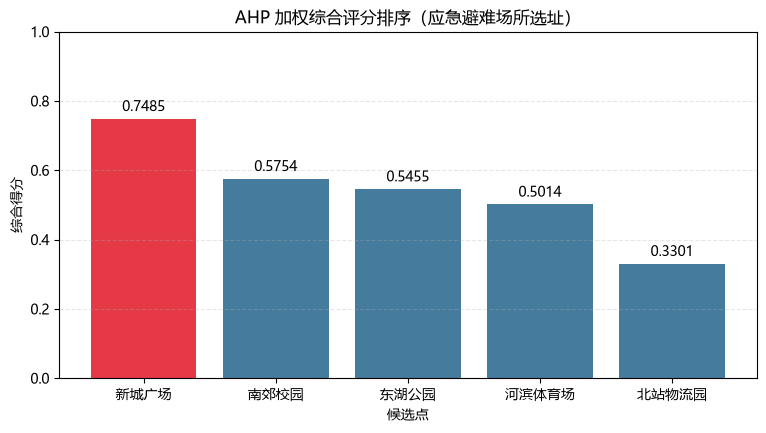

In [26]:
# ============================================================
# 七、AHP 加权综合评分与排序
# 输入：正向化矩阵 z（见第六章 cell）、全局权重 global_weights（见 5.3 节 cell）
# 输出：综合得分表 + 排序条形图
# 公式：F_i = Σ_j w_j * z_ij，F 越大越优
# 说明：本 cell 自包含（自带 import 与核心数据），可独立运行
# ============================================================

# 本 cell 使用 numpy/pandas/matplotlib，独立导入（不依赖前面的 cell）。
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文显示（保证独立运行时中文不变成方块）。
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 案例数据（与准备工作 cell 一致，保证本 cell 可独立运行）。
names = ["东湖公园", "河滨体育场", "新城广场", "北站物流园", "南郊校园"]

indicators = [
    "地质与消防安全评分", "洪涝风险指数", "平均疏散时间_min", "最近医疗点距离_km",
    "可用面积_万m2", "服务覆盖人口_万人", "建设成本_百万元", "生态扰动指数",
]

indicator_types = {
    "地质与消防安全评分": "benefit", "洪涝风险指数": "cost",
    "平均疏散时间_min": "cost", "最近医疗点距离_km": "cost",
    "可用面积_万m2": "benefit", "服务覆盖人口_万人": "benefit",
    "建设成本_百万元": "cost", "生态扰动指数": "cost",
}

raw = np.array([
    [88, 0.18, 18, 2.4, 4.8, 7.2, 42, 0.22],
    [82, 0.32, 14, 1.2, 3.9, 8.5, 36, 0.35],
    [90, 0.12, 16, 1.8, 3.2, 9.1, 48, 0.18],
    [78, 0.20, 22, 3.0, 6.5, 6.0, 32, 0.48],
    [86, 0.15, 20, 0.9, 5.2, 6.8, 40, 0.15],
], dtype=float)

# ---- 正互反矩阵与权重计算函数（与 5.1/5.2 节一致，保证本 cell 可独立运行）----
CRITERIA_MATRIX = np.array([
    [1, 2, 1, 3], [1/2, 1, 1/2, 2], [1, 2, 1, 3], [1/3, 1/2, 1/3, 1],
], dtype=float)

LOCAL_MATRICES = {
    "安全性": np.array([[1, 1/2], [2, 1]], dtype=float),
    "可达性": np.array([[1, 2], [1/2, 1]], dtype=float),
    "承载能力": np.array([[1, 1/2], [2, 1]], dtype=float),
    "经济与环境": np.array([[1, 2], [1/2, 1]], dtype=float),
}

def ahp_weight(matrix):
    """特征向量法：取最大特征值对应的主特征向量，归一化后作为权重。"""
    A = np.asarray(matrix, dtype=float)
    eigenvalues, eigenvectors = np.linalg.eig(A)
    max_index = int(np.argmax(eigenvalues.real))
    vector = np.abs(eigenvectors[:, max_index].real)
    return vector / vector.sum()

def minmax_positive(matrix, types):
    """极差标准化并统一正向化，使所有指标都满足"越大越优"。"""
    x = np.asarray(matrix, dtype=float)
    z = np.zeros_like(x, dtype=float)
    for j, kind in enumerate(types):
        col = x[:, j]
        minimum, maximum = col.min(), col.max()
        span = maximum - minimum
        if np.isclose(span, 0.0):
            z[:, j] = 1.0
        elif kind == "benefit":
            z[:, j] = (col - minimum) / span
        else:
            z[:, j] = (maximum - col) / span
    return z

# ---- 计算正向化矩阵与全局权重（保证本 cell 可独立运行）----
types = [indicator_types[name] for name in indicators]
z = minmax_positive(raw, types)

criteria_names = list(LOCAL_MATRICES.keys())
criteria_weight = ahp_weight(CRITERIA_MATRIX)
global_weights = []
for k, name in enumerate(criteria_names):
    local_weight = ahp_weight(LOCAL_MATRICES[name])
    global_weights.extend((criteria_weight[k] * local_weight).tolist())
global_weights = np.asarray(global_weights, dtype=float)
global_weights /= global_weights.sum()

# ---- AHP 加权综合评分 ----
# 矩阵乘法一步完成加权求和：z 是 (5, 8)，权重是 (8,)。
scores = z @ global_weights

# 按得分降序排序并展示结果表。
order = np.argsort(-scores)
result_table = pd.DataFrame({
    "候选点": [names[i] for i in order],
    "综合得分": scores[order],
    "排名": range(1, len(names) + 1),
})
print("=== AHP 加权综合评分（层次总排序结果）===")
print(result_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# 绘制得分条形图，直观展示排序结果。
plt.figure(figsize=(9, 4.5))
colors = ["#E63946"] + ["#457B9D"] * (len(names) - 1)   # 第 1 名用红色突出
bars = plt.bar(result_table["候选点"], result_table["综合得分"], color=colors)
plt.bar_label(bars, labels=[f"{x:.4f}" for x in result_table["综合得分"]], padding=3)
plt.ylim(0, 1)
plt.xlabel("候选点"); plt.ylabel("综合得分")
plt.title("AHP 加权综合评分排序（应急避难场所选址）")
plt.grid(axis="y", ls="--", alpha=0.3)
plt.show()

# 结论：新城广场 > 南郊校园 > 东湖公园 > 河滨体育场 > 北站物流园。
# 结果验证：新城广场 0.7485、南郊校园 0.5754、东湖公园 0.5455、
# 河滨体育场 0.5014、北站物流园 0.3301。


# 八、进阶：AHP-TOPSIS 组合评价

## 方法原理

TOPSIS（逼近理想解排序法）的基本思想：**最好的方案应距正理想解最近、距负理想解最远**。

对正向化矩阵做向量规范化后乘 AHP 权重，得到加权规范化矩阵 $V$，再构造：

$$V^+ = \left(\max_i v_{i1},\ \max_i v_{i2},\ \dots,\ \max_i v_{im}\right) \quad \text{正理想解（各指标最优值）}$$

$$V^- = \left(\min_i v_{i1},\ \min_i v_{i2},\ \dots,\ \min_i v_{im}\right) \quad \text{负理想解（各指标最差值）}$$

方案 $i$ 到正、负理想解的欧氏距离：

$$D_i^+ = \sqrt{\sum_{j=1}^{m}\left(v_{ij} - v_j^+\right)^2}, \qquad D_i^- = \sqrt{\sum_{j=1}^{m}\left(v_{ij} - v_j^-\right)^2}$$

**相对贴近度**（越大越优）：

$$C_i = \frac{D_i^-}{D_i^+ + D_i^-} \in [0, 1]$$

- **输入**：正向化矩阵、AHP 权重
- **输出**：各方案贴近度与排序
- **优点**：同时考虑"靠近最优"与"远离最差"，比简单加权和更精细；对指标补偿方式更敏感
- **缺点**：距离计算受指标间量纲与相关性的影响；归一化方式不同结果可能不同
- **适用场景**：与 AHP 加权评分并列做**对比验证**，或与熵权法等客观赋权组合成"熵权-TOPSIS"

<span style="color:#c0392b">**⚠️ 注意：**</span> 本案例中 AHP-TOPSIS 与简单加权评分的**第 2、3 名互换**（加权：南郊第 2、东湖第 3；TOPSIS：东湖第 2、南郊第 3），说明"指标补偿方式"也会影响排序——这正是论文中需要多模型对比的原因。


In [27]:
# ============================================================
# 八、AHP-TOPSIS 组合评价
# 输入：正向化矩阵 z、AHP 权重 global_weights
# 输出：各方案贴近度 C_i 与排序（越大越优）
# 优点：同时考虑"靠近正理想解、远离负理想解"
# 缺点：对指标补偿方式敏感，可能与加权评分结果略有差异
# 适用场景：与 AHP 加权评分做对比验证
# 说明：本 cell 自包含（自带 import 与核心数据），可独立运行
# ============================================================

# 本 cell 使用 numpy，独立导入（不依赖前面的 cell）。
import numpy as np

# 案例数据（与准备工作 cell 一致，保证本 cell 可独立运行）。
names = ["东湖公园", "河滨体育场", "新城广场", "北站物流园", "南郊校园"]

indicators = [
    "地质与消防安全评分", "洪涝风险指数", "平均疏散时间_min", "最近医疗点距离_km",
    "可用面积_万m2", "服务覆盖人口_万人", "建设成本_百万元", "生态扰动指数",
]

indicator_types = {
    "地质与消防安全评分": "benefit", "洪涝风险指数": "cost",
    "平均疏散时间_min": "cost", "最近医疗点距离_km": "cost",
    "可用面积_万m2": "benefit", "服务覆盖人口_万人": "benefit",
    "建设成本_百万元": "cost", "生态扰动指数": "cost",
}

raw = np.array([
    [88, 0.18, 18, 2.4, 4.8, 7.2, 42, 0.22],
    [82, 0.32, 14, 1.2, 3.9, 8.5, 36, 0.35],
    [90, 0.12, 16, 1.8, 3.2, 9.1, 48, 0.18],
    [78, 0.20, 22, 3.0, 6.5, 6.0, 32, 0.48],
    [86, 0.15, 20, 0.9, 5.2, 6.8, 40, 0.15],
], dtype=float)

CRITERIA_MATRIX = np.array([
    [1, 2, 1, 3], [1/2, 1, 1/2, 2], [1, 2, 1, 3], [1/3, 1/2, 1/3, 1],
], dtype=float)

LOCAL_MATRICES = {
    "安全性": np.array([[1, 1/2], [2, 1]], dtype=float),
    "可达性": np.array([[1, 2], [1/2, 1]], dtype=float),
    "承载能力": np.array([[1, 1/2], [2, 1]], dtype=float),
    "经济与环境": np.array([[1, 2], [1/2, 1]], dtype=float),
}

def ahp_weight(matrix):
    """特征向量法：取最大特征值对应的主特征向量，归一化后作为权重。"""
    A = np.asarray(matrix, dtype=float)
    eigenvalues, eigenvectors = np.linalg.eig(A)
    max_index = int(np.argmax(eigenvalues.real))
    vector = np.abs(eigenvectors[:, max_index].real)
    return vector / vector.sum()

def minmax_positive(matrix, types):
    """极差标准化并统一正向化，使所有指标都满足"越大越优"。"""
    x = np.asarray(matrix, dtype=float)
    z = np.zeros_like(x, dtype=float)
    for j, kind in enumerate(types):
        col = x[:, j]
        minimum, maximum = col.min(), col.max()
        span = maximum - minimum
        if np.isclose(span, 0.0):
            z[:, j] = 1.0
        elif kind == "benefit":
            z[:, j] = (col - minimum) / span
        else:
            z[:, j] = (maximum - col) / span
    return z

def topsis(positive_matrix, weights):
    """TOPSIS 相对贴近度计算。

    步骤：
    1. 向量规范化：v_ij = z_ij / sqrt(Σ_i z_ij^2)，消除量纲；
    2. 乘权重得到加权规范化矩阵：V_ij = v_ij * w_j；
    3. 构造正理想解 V+（各列最大值）与负理想解 V-（各列最小值）；
    4. 计算各方案到 V+、V- 的欧氏距离 D+、D-；
    5. 贴近度 C = D- / (D+ + D-)，C 越大越优。
    """
    z = np.asarray(positive_matrix, dtype=float)
    w = np.asarray(weights, dtype=float)

    # 1. 向量规范化（除以各列的欧氏长度）。
    norm = np.sqrt(np.sum(z ** 2, axis=0))
    normalized = np.divide(z, norm, out=np.zeros_like(z), where=~np.isclose(norm, 0.0))

    # 2. 乘 AHP 权重 → 加权规范化矩阵。
    weighted = normalized * w

    # 3. 正、负理想解。
    ideal_best = weighted.max(axis=0)
    ideal_worst = weighted.min(axis=0)

    # 4. 欧氏距离。
    d_plus = np.sqrt(np.sum((weighted - ideal_best) ** 2, axis=1))
    d_minus = np.sqrt(np.sum((weighted - ideal_worst) ** 2, axis=1))

    # 5. 相对贴近度（分母为 0 的退化情况赋 0.5）。
    denominator = d_plus + d_minus
    closeness = np.divide(d_minus, denominator,
                          out=np.full_like(d_minus, 0.5),
                          where=~np.isclose(denominator, 0.0))
    return closeness

# ---- 计算正向化矩阵与全局权重（保证本 cell 可独立运行）----
types = [indicator_types[name] for name in indicators]
z = minmax_positive(raw, types)

criteria_weight = ahp_weight(CRITERIA_MATRIX)
global_weights = []
for k, name in enumerate(LOCAL_MATRICES):
    local_weight = ahp_weight(LOCAL_MATRICES[name])
    global_weights.extend((criteria_weight[k] * local_weight).tolist())
global_weights = np.asarray(global_weights, dtype=float)
global_weights /= global_weights.sum()

# 计算 AHP-TOPSIS 贴近度并排序。
topsis_score = topsis(z, global_weights)
order_t = np.argsort(-topsis_score)

print("=== AHP-TOPSIS 贴近度与排序 ===")
for rank, idx in enumerate(order_t, start=1):
    print(f"  第{rank}名: {names[idx]}  C = {topsis_score[idx]:.4f}")

# 对比简单加权评分（见第七章结果），观察排序差异：
# 加权评分: 新城 > 南郊 > 东湖 > 河滨 > 北站
# TOPSIS  : 新城 > 东湖 > 南郊 > 河滨 > 北站
# 差异原因：TOPSIS 按"到理想解距离"比较，补偿方式与加权和不同。


=== AHP-TOPSIS 贴近度与排序 ===
  第1名: 新城广场  C = 0.6962
  第2名: 东湖公园  C = 0.5261
  第3名: 南郊校园  C = 0.5129
  第4名: 河滨体育场  C = 0.5037
  第5名: 北站物流园  C = 0.3802


# 九、进阶：其他综合评价模型（组合对比）

AHP 提供了**主观权重**，但评价类题目常需要**多模型交叉验证**来增强结论的说服力。本章介绍四种与 AHP 权重配合使用的经典综合评价模型，并与第七章的 AHP 加权评分、第八章的 AHP-TOPSIS 做对比：

| 模型 | 权重来源 | 核心思想 | 本案例排序（前 3） |
|------|---------|---------|-------------------|
| **CRITIC-TOPSIS** | CRITIC 客观赋权 | 对比强度 + 指标冲突 | 南郊 > 河滨 > 北站 |
| **VIKOR 折中排序** | 组合权重（AHP+熵权+CRITIC） | 群体效用 + 个体遗憾折中 | 新城 > 东湖 > 南郊 |
| **灰色关联分析** | AHP 主观赋权 | 与理想序列的几何接近度 | 新城 > 南郊 > 河滨 |
| **模糊综合评价** | AHP 主观赋权 | 隶属度 + 模糊合成 | 新城 > 南郊 > 东湖 |

<span style="color:#c0392b">**⚠️ 为什么需要多模型对比？**</span> 不同模型对"指标补偿方式"的处理不同（加权和允许短板被长板补偿、TOPSIS 按距离比较、VIKOR 追求折中、灰色关联衡量曲线接近度），排序结果可能略有差异——**差异不是计算错误，而是模型机制不同**。论文中常用多模型 + Borda 集成（按名次打分汇总）得到稳健的最终排名。


## 9.1 CRITIC-TOPSIS：客观赋权 + 距离排序

### 方法原理

CRITIC（Criteria Importance Through Intercriteria Correlation）是一种**完全客观**的赋权法，权重由数据本身决定，不需要专家判断：

$$C_j = \sigma_j \sum_{k=1}^{m} (1 - r_{jk}), \qquad w_j = \frac{C_j}{\sum_{j=1}^{m} C_j}$$

其中：
- $\sigma_j$：指标 $j$ 的**标准差**（对比强度）——数据差异越大，区分能力越强
- $r_{jk}$：指标 $j$ 与指标 $k$ 的**相关系数**——与其他指标相关性越低，独立信息越多
- $C_j$：指标 $j$ 的**信息量**，归一化后即权重

权重确定后，用第八章的 TOPSIS 计算各方案贴近度并排序。

- **输入**：正向化矩阵（仅数据，无需专家判断）
- **输出**：CRITIC 权重 + TOPSIS 贴近度排序
- **优点**：完全客观、可复现；同时考虑离散程度与指标冲突
- **缺点**：不理解指标的政策/业务重要性；对数据质量敏感
- **适用场景**：数据丰富、需要客观权重佐证 AHP 主观权重时

<span style="color:#c0392b">**⚠️ 注意：**</span> 本案例 CRITIC 对"可用面积"和"建设成本"赋权较高，导致**新城广场（面积最小、成本最高）排到末位**——这与 AHP 下它排第 1 完全相反。这正是"主观 vs 客观"权重差异的典型体现，也是多模型对比的价值所在。

## 本案例结果（供代码验证）

CRITIC-TOPSIS 排序：**南郊校园 > 河滨体育场 > 北站物流园 > 东湖公园 > 新城广场**


In [28]:
# ============================================================
# 9.1 CRITIC-TOPSIS：客观赋权 + TOPSIS 排序
# 输入：正向化矩阵 z（越大越优）
# 输出：CRITIC 权重 + 贴近度排序
# 公式：C_j = σ_j * Σ_k(1 - r_jk)；w_j = C_j / ΣC_j
# 说明：本 cell 自包含（自带 import 与核心数据），可独立运行
# ============================================================

# 本 cell 使用 numpy，独立导入（不依赖前面的 cell）。
import numpy as np

# 案例数据（与准备工作 cell 一致，保证本 cell 可独立运行）。
names = ["东湖公园", "河滨体育场", "新城广场", "北站物流园", "南郊校园"]
indicators = [
    "地质与消防安全评分", "洪涝风险指数", "平均疏散时间_min", "最近医疗点距离_km",
    "可用面积_万m2", "服务覆盖人口_万人", "建设成本_百万元", "生态扰动指数",
]
indicator_types = {
    "地质与消防安全评分": "benefit", "洪涝风险指数": "cost",
    "平均疏散时间_min": "cost", "最近医疗点距离_km": "cost",
    "可用面积_万m2": "benefit", "服务覆盖人口_万人": "benefit",
    "建设成本_百万元": "cost", "生态扰动指数": "cost",
}
raw = np.array([
    [88, 0.18, 18, 2.4, 4.8, 7.2, 42, 0.22],
    [82, 0.32, 14, 1.2, 3.9, 8.5, 36, 0.35],
    [90, 0.12, 16, 1.8, 3.2, 9.1, 48, 0.18],
    [78, 0.20, 22, 3.0, 6.5, 6.0, 32, 0.48],
    [86, 0.15, 20, 0.9, 5.2, 6.8, 40, 0.15],
], dtype=float)

def minmax_positive(matrix, types):
    """极差标准化并统一正向化，使所有指标都满足"越大越优"。"""
    x = np.asarray(matrix, dtype=float)
    z = np.zeros_like(x, dtype=float)
    for j, kind in enumerate(types):
        col = x[:, j]
        minimum, maximum = col.min(), col.max()
        span = maximum - minimum
        if np.isclose(span, 0.0):
            z[:, j] = 1.0
        elif kind == "benefit":
            z[:, j] = (col - minimum) / span
        else:
            z[:, j] = (maximum - col) / span
    return z

def critic_weight(positive_matrix):
    """CRITIC 客观权重：同时考虑对比强度（标准差）与指标冲突（1 - 相关系数）。"""
    z = np.asarray(positive_matrix, dtype=float)
    std = z.std(axis=0, ddof=0)                              # 对比强度：标准差
    corr = np.corrcoef(z, rowvar=False)                      # 指标间相关系数矩阵
    corr = np.nan_to_num(corr, nan=0.0)
    conflict = np.sum(1.0 - corr, axis=1)                    # 指标冲突程度
    information = std * conflict                             # 信息量 C_j
    if np.isclose(information.sum(), 0.0):
        return np.full(z.shape[1], 1.0 / z.shape[1])
    return information / information.sum()

def topsis(positive_matrix, weights):
    """TOPSIS 相对贴近度（与第八章一致，越大越优）。"""
    z = np.asarray(positive_matrix, dtype=float)
    w = np.asarray(weights, dtype=float)
    norm = np.sqrt(np.sum(z ** 2, axis=0))
    normalized = np.divide(z, norm, out=np.zeros_like(z), where=~np.isclose(norm, 0.0))
    weighted = normalized * w
    ideal_best = weighted.max(axis=0)
    ideal_worst = weighted.min(axis=0)
    d_plus = np.sqrt(np.sum((weighted - ideal_best) ** 2, axis=1))
    d_minus = np.sqrt(np.sum((weighted - ideal_worst) ** 2, axis=1))
    denominator = d_plus + d_minus
    return np.divide(d_minus, denominator,
                     out=np.full_like(d_minus, 0.5),
                     where=~np.isclose(denominator, 0.0))

# ---- 计算 CRITIC 权重并做 TOPSIS 排序 ----
types = [indicator_types[name] for name in indicators]
z = minmax_positive(raw, types)
w_critic = critic_weight(z)
score_critic = topsis(z, w_critic)
order_c = np.argsort(-score_critic)

print("=== CRITIC 客观权重 ===")
for name, w in zip(indicators, w_critic):
    print(f"  {name}: {w:.4f}")

print("\n=== CRITIC-TOPSIS 排序（越大越优）===")
for rank, idx in enumerate(order_c, start=1):
    print(f"  第{rank}名: {names[idx]}  C = {score_critic[idx]:.4f}")

# 预期输出：南郊校园 > 河滨体育场 > 北站物流园 > 东湖公园 > 新城广场。
# 新城广场因面积最小、建设成本最高而排末位，与 AHP 结果形成鲜明对比。


=== CRITIC 客观权重 ===
  地质与消防安全评分: 0.1032
  洪涝风险指数: 0.1200
  平均疏散时间_min: 0.1161
  最近医疗点距离_km: 0.1089
  可用面积_万m2: 0.1665
  服务覆盖人口_万人: 0.1145
  建设成本_百万元: 0.1676
  生态扰动指数: 0.1032

=== CRITIC-TOPSIS 排序（越大越优）===
  第1名: 南郊校园  C = 0.5724
  第2名: 河滨体育场  C = 0.5263
  第3名: 北站物流园  C = 0.5150
  第4名: 东湖公园  C = 0.4978
  第5名: 新城广场  C = 0.4741


## 9.2 VIKOR 折中排序

### 方法原理

VIKOR（VlseKriterijumska Optimizacija I Kompromisno Resenje）通过**群体效用**与**个体遗憾**的折中寻找妥协解。设组合权重为 $w_j$（本案例取 $0.5 \times AHP + 0.25 \times 熵权 + 0.25 \times CRITIC$），正向化后理想值为 1，则各方案的加权遗憾为：

$$d_{ij} = w_j \cdot (1 - z_{ij})$$

**群体效用**（所有指标遗憾之和）与**个体最大遗憾**：

$$S_i = \sum_{j=1}^{m} d_{ij}, \qquad R_i = \max_j d_{ij}$$

**折中指标**（$v$ 为折中系数，本案例取 $v = 0.5$，$Q$ 越小越优，代码输出 $1-Q$ 统一为越大越优）：

$$Q_i = v \cdot \frac{S_i - S_{min}}{S_{max} - S_{min}} + (1-v) \cdot \frac{R_i - R_{min}}{R_{max} - R_{min}}$$

- **输入**：正向化矩阵、组合权重、折中系数 v
- **输出**：S（群体遗憾）、R（个体遗憾）、Q 及排序
- **优点**：兼顾"多数人利益"与"最差者利益"，适合利益冲突决策
- **缺点**：仅给出排名还不够，需检验**可接受优势**（第 1、2 名 Q 差 $\ge 1/(m-1)$）与**决策稳定性**（第 1 名同时是 S 或 R 最优）
- **适用场景**：方案间利益冲突明显、需要折中解的决策问题

## 本案例结果（供代码验证）

VIKOR 排序：**新城广场 > 东湖公园 > 南郊校园 > 河滨体育场 > 北站物流园**
第 1、2 名 Q 差仅为 0.0377 < 阈值 0.25，不满足"可接受优势"，故折中解集为 {新城广场、东湖公园、南郊校园}，**不能宣称存在唯一压倒性方案**。


In [29]:
# ============================================================
# 9.2 VIKOR 折中排序（组合权重：0.5 AHP + 0.25 熵权 + 0.25 CRITIC）
# 输入：正向化矩阵 z、组合权重、折中系数 v=0.5
# 输出：S（群体遗憾）、R（个体遗憾）、Q 折中值及排序
# 说明：本 cell 自包含（自带 import 与核心数据），可独立运行
# ============================================================

# 本 cell 使用 numpy，独立导入（不依赖前面的 cell）。
import numpy as np

# 案例数据（与准备工作 cell 一致，保证本 cell 可独立运行）。
names = ["东湖公园", "河滨体育场", "新城广场", "北站物流园", "南郊校园"]
indicators = [
    "地质与消防安全评分", "洪涝风险指数", "平均疏散时间_min", "最近医疗点距离_km",
    "可用面积_万m2", "服务覆盖人口_万人", "建设成本_百万元", "生态扰动指数",
]
indicator_types = {
    "地质与消防安全评分": "benefit", "洪涝风险指数": "cost",
    "平均疏散时间_min": "cost", "最近医疗点距离_km": "cost",
    "可用面积_万m2": "benefit", "服务覆盖人口_万人": "benefit",
    "建设成本_百万元": "cost", "生态扰动指数": "cost",
}
raw = np.array([
    [88, 0.18, 18, 2.4, 4.8, 7.2, 42, 0.22],
    [82, 0.32, 14, 1.2, 3.9, 8.5, 36, 0.35],
    [90, 0.12, 16, 1.8, 3.2, 9.1, 48, 0.18],
    [78, 0.20, 22, 3.0, 6.5, 6.0, 32, 0.48],
    [86, 0.15, 20, 0.9, 5.2, 6.8, 40, 0.15],
], dtype=float)

CRITERIA_MATRIX = np.array([
    [1, 2, 1, 3], [1/2, 1, 1/2, 2], [1, 2, 1, 3], [1/3, 1/2, 1/3, 1],
], dtype=float)

LOCAL_MATRICES = {
    "安全性": np.array([[1, 1/2], [2, 1]], dtype=float),
    "可达性": np.array([[1, 2], [1/2, 1]], dtype=float),
    "承载能力": np.array([[1, 1/2], [2, 1]], dtype=float),
    "经济与环境": np.array([[1, 2], [1/2, 1]], dtype=float),
}

def ahp_weight(matrix):
    """特征向量法：取最大特征值对应的主特征向量，归一化后作为权重。"""
    A = np.asarray(matrix, dtype=float)
    eigenvalues, eigenvectors = np.linalg.eig(A)
    max_index = int(np.argmax(eigenvalues.real))
    vector = np.abs(eigenvectors[:, max_index].real)
    return vector / vector.sum()

def minmax_positive(matrix, types):
    """极差标准化并统一正向化，使所有指标都满足"越大越优"。"""
    x = np.asarray(matrix, dtype=float)
    z = np.zeros_like(x, dtype=float)
    for j, kind in enumerate(types):
        col = x[:, j]
        minimum, maximum = col.min(), col.max()
        span = maximum - minimum
        if np.isclose(span, 0.0):
            z[:, j] = 1.0
        elif kind == "benefit":
            z[:, j] = (col - minimum) / span
        else:
            z[:, j] = (maximum - col) / span
    return z

def critic_weight(positive_matrix):
    """CRITIC 客观权重：对比强度（标准差）× 指标冲突（1 - 相关系数）。"""
    z = np.asarray(positive_matrix, dtype=float)
    std = z.std(axis=0, ddof=0)
    corr = np.corrcoef(z, rowvar=False)
    corr = np.nan_to_num(corr, nan=0.0)
    information = std * np.sum(1.0 - corr, axis=1)
    if np.isclose(information.sum(), 0.0):
        return np.full(z.shape[1], 1.0 / z.shape[1])
    return information / information.sum()

def entropy_weight(positive_matrix):
    """熵权法：离散程度越大的指标提供的信息越多，权重越高。"""
    z = np.asarray(positive_matrix, dtype=float)
    n = z.shape[0]
    eps = 1e-12
    column_sum = z.sum(axis=0)
    p = np.divide(z, column_sum,
                  out=np.full_like(z, 1.0 / n),
                  where=~np.isclose(column_sum, 0.0))
    entropy = -1.0 / np.log(n) * np.sum(p * np.log(p + eps), axis=0)
    divergence = np.clip(1.0 - entropy, 0.0, None)
    if np.isclose(divergence.sum(), 0.0):
        return np.full(z.shape[1], 1.0 / z.shape[1])
    return divergence / divergence.sum()

def vikor(positive_matrix, weights, v=0.5):
    """VIKOR 折中排序。

    S：群体遗憾（所有指标加权差距之和）；R：个体最大遗憾。
    Q 越小越优；返回 score = 1 - Q 以便与其他模型统一"越大越优"。
    """
    z = np.asarray(positive_matrix, dtype=float)
    w = np.asarray(weights, dtype=float)
    regret = (1.0 - z) * w                              # 各指标加权差距
    s = regret.sum(axis=1)                             # 群体效用遗憾
    r = regret.max(axis=1)                             # 个体最大遗憾

    def scale(values):
        span = values.max() - values.min()
        if np.isclose(span, 0.0):
            return np.zeros_like(values)
        return (values - values.min()) / span

    q = v * scale(s) + (1 - v) * scale(r)              # 折中指标（越小越优）
    return 1.0 - q, s, r                               # score = 1 - Q（越大越优）

# ---- 计算三套权重并合成组合权重 ----
types = [indicator_types[name] for name in indicators]
z = minmax_positive(raw, types)

criteria_weight = ahp_weight(CRITERIA_MATRIX)
w_ahp = []
for k, name in enumerate(LOCAL_MATRICES):
    local = ahp_weight(LOCAL_MATRICES[name])
    w_ahp.extend((criteria_weight[k] * local).tolist())
w_ahp = np.asarray(w_ahp) / np.sum(w_ahp)

w_entropy = entropy_weight(z)
w_critic = critic_weight(z)
w_comb = 0.5 * w_ahp + 0.25 * w_entropy + 0.25 * w_critic
w_comb /= w_comb.sum()                                 # 组合权重归一化

# ---- VIKOR 计算与排序 ----
score_v, s_v, r_v = vikor(z, w_comb, v=0.5)
order_v = np.argsort(-score_v)

print("=== 组合权重（0.5 AHP + 0.25 熵权 + 0.25 CRITIC）===")
for name, w in zip(indicators, w_comb):
    print(f"  {name}: {w:.4f}")

print("\n=== VIKOR 折中排序（score = 1 - Q，越大越优）===")
for rank, idx in enumerate(order_v, start=1):
    print(f"  第{rank}名: {names[idx]}  S={s_v[idx]:.4f}, R={r_v[idx]:.4f}, score={score_v[idx]:.4f}")

# 可接受优势检验：阈值 = 1/(m-1) = 0.25。
m = len(names)
threshold = 1.0 / (m - 1)
q_values = 1.0 - score_v
q_sorted = np.sort(q_values)
gap = q_sorted[1] - q_sorted[0]
print(f"\n可接受优势阈值 = 1/(m-1) = {threshold:.2f}，第1、2名Q差 = {gap:.4f}")
print("→", "✅ 满足可接受优势" if gap >= threshold else "❌ 不满足可接受优势，折中解集不止一个方案")

# 预期输出：新城广场 > 东湖公园 > 南郊校园 > 河滨体育场 > 北站物流园。
# 第1、2名Q差仅0.0377 < 0.25，不能宣称唯一最优，折中解集为前3名。


=== 组合权重（0.5 AHP + 0.25 熵权 + 0.25 CRITIC）===
  地质与消防安全评分: 0.1140
  洪涝风险指数: 0.1718
  平均疏散时间_min: 0.1259
  最近医疗点距离_km: 0.0908
  可用面积_万m2: 0.1359
  服务覆盖人口_万人: 0.1815
  建设成本_百万元: 0.1080
  生态扰动指数: 0.0721

=== VIKOR 折中排序（score = 1 - Q，越大越优）===
  第1名: 新城广场  S=0.3209, R=0.1359, score=0.8247
  第2名: 东湖公园  S=0.4624, R=0.1112, score=0.7869
  第3名: 南郊校园  S=0.4004, R=0.1346, score=0.7136
  第4名: 河滨体育场  S=0.4736, R=0.1718, score=0.3390
  第5名: 北站物流园  S=0.6530, R=0.1815, score=0.0000

可接受优势阈值 = 1/(m-1) = 0.25，第1、2名Q差 = 0.0377
→ ❌ 不满足可接受优势，折中解集不止一个方案


## 9.3 灰色关联分析（GRA）

### 方法原理

灰色关联分析（Grey Relational Analysis）衡量各方案序列与**理想序列**（正向化后理想值为全 1）之间的**几何接近程度**：曲线越贴近理想序列，方案越优。

以全 1 向量为参考序列，差序列为 $\Delta_{ij} = |z_{ij} - 1|$，灰色关联系数为：

$$\xi_{ij} = \frac{\Delta_{min} + \rho \cdot \Delta_{max}}{\Delta_{ij} + \rho \cdot \Delta_{max}}, \qquad \rho = 0.5$$

其中 $\rho$ 为**分辨系数**（一般取 0.5），$\Delta_{min}$、$\Delta_{max}$ 为差序列的最小、最大值。最后用 AHP 权重合成各方案的综合关联度：

$$r_i = \sum_{j=1}^{m} w_j \cdot \xi_{ij}$$

- **输入**：正向化矩阵、AHP 权重、分辨系数 ρ
- **输出**：各方案综合关联度与排序（越大越优）
- **优点**：小样本、信息不完全时依然适用；对数据分布无严格要求
- **缺点**：ρ 的取值影响结果；只衡量与理想序列的接近度，不体现方案间优劣差异的细节
- **适用场景**：样本量小、指标间关系不明确的评价问题

## 本案例结果（供代码验证）

灰色关联排序：**新城广场 > 南郊校园 > 河滨体育场 > 东湖公园 > 北站物流园**


In [30]:
# ============================================================
# 9.3 灰色关联分析（GRA）
# 输入：正向化矩阵 z、AHP 权重、分辨系数 rho=0.5
# 输出：各方案综合关联度与排序（越大越优）
# 公式：ξ_ij = (Δmin + ρ·Δmax) / (Δ_ij + ρ·Δmax)；r_i = Σ_j w_j·ξ_ij
# 说明：本 cell 自包含（自带 import 与核心数据），可独立运行
# ============================================================

# 本 cell 使用 numpy，独立导入（不依赖前面的 cell）。
import numpy as np

# 案例数据（与准备工作 cell 一致，保证本 cell 可独立运行）。
names = ["东湖公园", "河滨体育场", "新城广场", "北站物流园", "南郊校园"]
indicators = [
    "地质与消防安全评分", "洪涝风险指数", "平均疏散时间_min", "最近医疗点距离_km",
    "可用面积_万m2", "服务覆盖人口_万人", "建设成本_百万元", "生态扰动指数",
]
indicator_types = {
    "地质与消防安全评分": "benefit", "洪涝风险指数": "cost",
    "平均疏散时间_min": "cost", "最近医疗点距离_km": "cost",
    "可用面积_万m2": "benefit", "服务覆盖人口_万人": "benefit",
    "建设成本_百万元": "cost", "生态扰动指数": "cost",
}
raw = np.array([
    [88, 0.18, 18, 2.4, 4.8, 7.2, 42, 0.22],
    [82, 0.32, 14, 1.2, 3.9, 8.5, 36, 0.35],
    [90, 0.12, 16, 1.8, 3.2, 9.1, 48, 0.18],
    [78, 0.20, 22, 3.0, 6.5, 6.0, 32, 0.48],
    [86, 0.15, 20, 0.9, 5.2, 6.8, 40, 0.15],
], dtype=float)

CRITERIA_MATRIX = np.array([
    [1, 2, 1, 3], [1/2, 1, 1/2, 2], [1, 2, 1, 3], [1/3, 1/2, 1/3, 1],
], dtype=float)

LOCAL_MATRICES = {
    "安全性": np.array([[1, 1/2], [2, 1]], dtype=float),
    "可达性": np.array([[1, 2], [1/2, 1]], dtype=float),
    "承载能力": np.array([[1, 1/2], [2, 1]], dtype=float),
    "经济与环境": np.array([[1, 2], [1/2, 1]], dtype=float),
}

def ahp_weight(matrix):
    """特征向量法：取最大特征值对应的主特征向量，归一化后作为权重。"""
    A = np.asarray(matrix, dtype=float)
    eigenvalues, eigenvectors = np.linalg.eig(A)
    max_index = int(np.argmax(eigenvalues.real))
    vector = np.abs(eigenvectors[:, max_index].real)
    return vector / vector.sum()

def minmax_positive(matrix, types):
    """极差标准化并统一正向化，使所有指标都满足"越大越优"。"""
    x = np.asarray(matrix, dtype=float)
    z = np.zeros_like(x, dtype=float)
    for j, kind in enumerate(types):
        col = x[:, j]
        minimum, maximum = col.min(), col.max()
        span = maximum - minimum
        if np.isclose(span, 0.0):
            z[:, j] = 1.0
        elif kind == "benefit":
            z[:, j] = (col - minimum) / span
        else:
            z[:, j] = (maximum - col) / span
    return z

def grey_relational_analysis(positive_matrix, weights, rho=0.5):
    """灰色关联分析：衡量各方案序列与理想序列（全 1）的几何接近程度。"""
    z = np.asarray(positive_matrix, dtype=float)
    w = np.asarray(weights, dtype=float)

    # 差序列：与理想值 1 的绝对距离。
    difference = np.abs(z - 1.0)
    delta_min, delta_max = difference.min(), difference.max()

    # 灰色关联系数（rho 为分辨系数，通常取 0.5）。
    coefficient = (delta_min + rho * delta_max) / (difference + rho * delta_max)

    # 用 AHP 权重合成综合关联度。
    return coefficient @ w

# ---- 计算 AHP 权重并做灰色关联分析 ----
types = [indicator_types[name] for name in indicators]
z = minmax_positive(raw, types)

criteria_weight = ahp_weight(CRITERIA_MATRIX)
w_ahp = []
for k, name in enumerate(LOCAL_MATRICES):
    local = ahp_weight(LOCAL_MATRICES[name])
    w_ahp.extend((criteria_weight[k] * local).tolist())
w_ahp = np.asarray(w_ahp) / np.sum(w_ahp)

grey_score = grey_relational_analysis(z, w_ahp, rho=0.5)
order_g = np.argsort(-grey_score)

print("=== 灰色关联分析排序（rho=0.5，AHP 权重合成）===")
for rank, idx in enumerate(order_g, start=1):
    print(f"  第{rank}名: {names[idx]}  关联度 = {grey_score[idx]:.4f}")

# 预期输出：新城广场 > 南郊校园 > 河滨体育场 > 东湖公园 > 北站物流园。


=== 灰色关联分析排序（rho=0.5，AHP 权重合成）===
  第1名: 新城广场  关联度 = 0.7968
  第2名: 南郊校园  关联度 = 0.5959
  第3名: 河滨体育场  关联度 = 0.5822
  第4名: 东湖公园  关联度 = 0.5435
  第5名: 北站物流园  关联度 = 0.5118


## 9.4 模糊综合评价

### 方法原理

模糊综合评价用**隶属度函数**把精确指标映射为"很差、较差、中等、良好、优秀"等语言等级的隶属程度，再用 AHP 权重做模糊合成。本案例采用五级**三角隶属度函数**，中心分别为 $0, 0.25, 0.5, 0.75, 1$，宽度 $0.25$：

$$\mu_k(z_{ij}) = \max\left(1 - \frac{|z_{ij} - c_k|}{0.25},\ 0\right), \qquad k = 1,2,\dots,5$$

每个方案形成模糊关系矩阵 $R_i$（指标 × 评价等级），用 AHP 权重合成综合隶属度向量：

$$B_i = w^T \cdot R_i$$

最后用评价等级分值 $(20, 40, 60, 80, 100)$ **解模糊**，得到各方案的百分制得分：

$$F_i = B_i \cdot (20, 40, 60, 80, 100)^T$$

- **输入**：正向化矩阵、AHP 权重、评价等级与分值
- **输出**：各方案综合隶属度 + 解模糊得分与排序
- **优点**：能承接"较好、一般"等语言评价；结果以百分制呈现，直观易懂
- **缺点**：隶属度函数的形式与等级划分有一定主观性
- **适用场景**：指标含语言变量、需要模糊等级输出的评价问题

## 本案例结果（供代码验证）

模糊综合评价得分：**新城广场（79.88）> 南郊校园（66.03）> 东湖公园（63.64）> 河滨体育场（60.11）> 北站物流园（46.41）**


In [31]:
# ============================================================
# 9.4 模糊综合评价（三角隶属度 + 模糊合成 + 解模糊）
# 输入：正向化矩阵 z、AHP 权重
# 输出：各方案综合隶属度向量 + 百分制得分与排序
# 公式：μ_k = max(1 - |z - c_k| / 0.25, 0)；B_i = w·R_i；F_i = B_i·分值
# 说明：本 cell 自包含（自带 import 与核心数据），可独立运行
# ============================================================

# 本 cell 使用 numpy，独立导入（不依赖前面的 cell）。
import numpy as np

# 案例数据（与准备工作 cell 一致，保证本 cell 可独立运行）。
names = ["东湖公园", "河滨体育场", "新城广场", "北站物流园", "南郊校园"]
indicators = [
    "地质与消防安全评分", "洪涝风险指数", "平均疏散时间_min", "最近医疗点距离_km",
    "可用面积_万m2", "服务覆盖人口_万人", "建设成本_百万元", "生态扰动指数",
]
indicator_types = {
    "地质与消防安全评分": "benefit", "洪涝风险指数": "cost",
    "平均疏散时间_min": "cost", "最近医疗点距离_km": "cost",
    "可用面积_万m2": "benefit", "服务覆盖人口_万人": "benefit",
    "建设成本_百万元": "cost", "生态扰动指数": "cost",
}
raw = np.array([
    [88, 0.18, 18, 2.4, 4.8, 7.2, 42, 0.22],
    [82, 0.32, 14, 1.2, 3.9, 8.5, 36, 0.35],
    [90, 0.12, 16, 1.8, 3.2, 9.1, 48, 0.18],
    [78, 0.20, 22, 3.0, 6.5, 6.0, 32, 0.48],
    [86, 0.15, 20, 0.9, 5.2, 6.8, 40, 0.15],
], dtype=float)

CRITERIA_MATRIX = np.array([
    [1, 2, 1, 3], [1/2, 1, 1/2, 2], [1, 2, 1, 3], [1/3, 1/2, 1/3, 1],
], dtype=float)

LOCAL_MATRICES = {
    "安全性": np.array([[1, 1/2], [2, 1]], dtype=float),
    "可达性": np.array([[1, 2], [1/2, 1]], dtype=float),
    "承载能力": np.array([[1, 1/2], [2, 1]], dtype=float),
    "经济与环境": np.array([[1, 2], [1/2, 1]], dtype=float),
}

def ahp_weight(matrix):
    """特征向量法：取最大特征值对应的主特征向量，归一化后作为权重。"""
    A = np.asarray(matrix, dtype=float)
    eigenvalues, eigenvectors = np.linalg.eig(A)
    max_index = int(np.argmax(eigenvalues.real))
    vector = np.abs(eigenvectors[:, max_index].real)
    return vector / vector.sum()

def minmax_positive(matrix, types):
    """极差标准化并统一正向化，使所有指标都满足"越大越优"。"""
    x = np.asarray(matrix, dtype=float)
    z = np.zeros_like(x, dtype=float)
    for j, kind in enumerate(types):
        col = x[:, j]
        minimum, maximum = col.min(), col.max()
        span = maximum - minimum
        if np.isclose(span, 0.0):
            z[:, j] = 1.0
        elif kind == "benefit":
            z[:, j] = (col - minimum) / span
        else:
            z[:, j] = (maximum - col) / span
    return z

def fuzzy_comprehensive(positive_matrix, weights):
    """五级三角隶属度模糊综合评价。

    评价集：{很差, 较差, 中等, 良好, 优秀}，中心 0/0.25/0.5/0.75/1，宽度 0.25；
    解模糊分值：(20, 40, 60, 80, 100)。
    """
    z = np.asarray(positive_matrix, dtype=float)
    w = np.asarray(weights, dtype=float)
    centers = np.linspace(0.0, 1.0, 5)
    width = 0.25
    grade_values = np.array([20, 40, 60, 80, 100], dtype=float)
    grades = ["很差", "较差", "中等", "良好", "优秀"]

    memberships = []
    for alternative in z:
        # 模糊关系矩阵 R_i：形状为（指标数 × 5 个评价等级）。
        relation = np.maximum(1.0 - np.abs(alternative[:, None] - centers[None, :]) / width, 0.0)
        relation /= relation.sum(axis=1, keepdims=True)     # 每行归一化
        memberships.append(w @ relation)                     # 综合隶属度 B_i = w·R_i
    membership_matrix = np.vstack(memberships)

    # 解模糊：百分制得分 = 综合隶属度 × 等级分值。
    crisp_score = membership_matrix @ grade_values
    return crisp_score, membership_matrix, grades

# ---- 计算 AHP 权重并做模糊综合评价 ----
types = [indicator_types[name] for name in indicators]
z = minmax_positive(raw, types)

criteria_weight = ahp_weight(CRITERIA_MATRIX)
w_ahp = []
for k, name in enumerate(LOCAL_MATRICES):
    local = ahp_weight(LOCAL_MATRICES[name])
    w_ahp.extend((criteria_weight[k] * local).tolist())
w_ahp = np.asarray(w_ahp) / np.sum(w_ahp)

fuzzy_score, fuzzy_membership, grades = fuzzy_comprehensive(z, w_ahp)
order_f = np.argsort(-fuzzy_score)

print("=== 模糊综合评价排序（解模糊百分制）===")
for rank, idx in enumerate(order_f, start=1):
    print(f"  第{rank}名: {names[idx]}  得分 = {fuzzy_score[idx]:.2f}")

# 展示新城广场的综合隶属度向量（可选参考）。
print("\n=== 新城广场综合隶属度（很差/较差/中等/良好/优秀）===")
print("  " + "  ".join(f"{g}: {v:.3f}" for g, v in zip(grades, fuzzy_membership[2])))

# 预期输出：新城广场 79.88 > 南郊校园 66.03 > 东湖公园 63.64 >
# 河滨体育场 60.11 > 北站物流园 46.41。


=== 模糊综合评价排序（解模糊百分制）===
  第1名: 新城广场  得分 = 79.88
  第2名: 南郊校园  得分 = 66.03
  第3名: 东湖公园  得分 = 63.64
  第4名: 河滨体育场  得分 = 60.11
  第5名: 北站物流园  得分 = 46.41

=== 新城广场综合隶属度（很差/较差/中等/良好/优秀）===
  很差: 0.190  较差: 0.000  中等: 0.045  良好: 0.157  优秀: 0.608


# 十、进阶：Monte Carlo 权重扰动敏感性分析

=== AHP 权重扰动下的稳定性（5000 次模拟）===
  候选点  成为第1名的概率   平均名次
 新城广场    0.9998 1.0002
 南郊校园    0.0002 2.2034
 东湖公园    0.0000 3.1022
河滨体育场    0.0000 3.7016
北站物流园    0.0000 4.9926


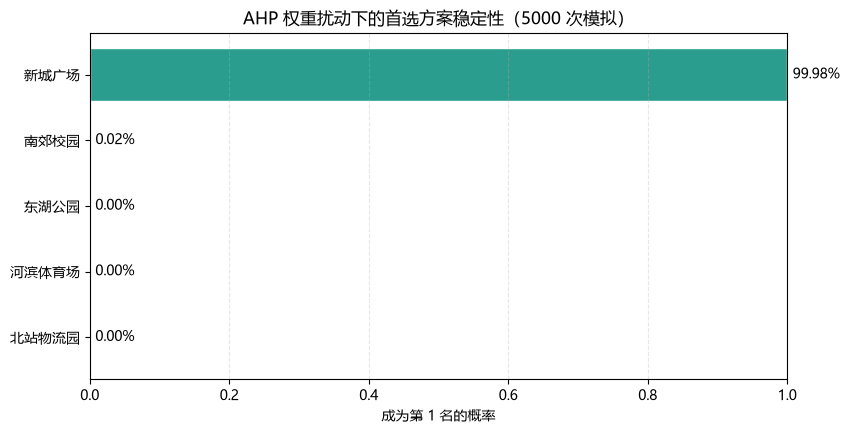

In [33]:
# ============================================================
# 十、Monte Carlo 权重扰动敏感性分析
# 输入：正向化矩阵 z（越大越优）、AHP 全局权重、模拟次数、集中度参数
# 输出：各方案成为第 1 名的概率、平均名次、概率条形图
# 优点：Dirichlet 扰动天然满足"非负且和为 1"，结论直观
# 缺点：只能检验 AHP 权重附近的扰动，覆盖不了完全不同的偏好
# 适用场景：论文"稳健性/敏感性分析"小节
# 说明：本 cell 自包含（自带 import 与核心数据），可独立运行
# ============================================================

# 本 cell 使用 numpy/pandas/matplotlib，独立导入（不依赖前面的 cell）。
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文显示（保证独立运行时中文不变成方块）。
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 案例数据（与准备工作 cell 一致，保证本 cell 可独立运行）。
names = ["东湖公园", "河滨体育场", "新城广场", "北站物流园", "南郊校园"]
indicators = [
    "地质与消防安全评分", "洪涝风险指数", "平均疏散时间_min", "最近医疗点距离_km",
    "可用面积_万m2", "服务覆盖人口_万人", "建设成本_百万元", "生态扰动指数",
]
indicator_types = {
    "地质与消防安全评分": "benefit", "洪涝风险指数": "cost",
    "平均疏散时间_min": "cost", "最近医疗点距离_km": "cost",
    "可用面积_万m2": "benefit", "服务覆盖人口_万人": "benefit",
    "建设成本_百万元": "cost", "生态扰动指数": "cost",
}
raw = np.array([
    [88, 0.18, 18, 2.4, 4.8, 7.2, 42, 0.22],
    [82, 0.32, 14, 1.2, 3.9, 8.5, 36, 0.35],
    [90, 0.12, 16, 1.8, 3.2, 9.1, 48, 0.18],
    [78, 0.20, 22, 3.0, 6.5, 6.0, 32, 0.48],
    [86, 0.15, 20, 0.9, 5.2, 6.8, 40, 0.15],
], dtype=float)

CRITERIA_MATRIX = np.array([
    [1, 2, 1, 3], [1/2, 1, 1/2, 2], [1, 2, 1, 3], [1/3, 1/2, 1/3, 1],
], dtype=float)

LOCAL_MATRICES = {
    "安全性": np.array([[1, 1/2], [2, 1]], dtype=float),
    "可达性": np.array([[1, 2], [1/2, 1]], dtype=float),
    "承载能力": np.array([[1, 1/2], [2, 1]], dtype=float),
    "经济与环境": np.array([[1, 2], [1/2, 1]], dtype=float),
}

def ahp_weight(matrix):
    """特征向量法：取最大特征值对应的主特征向量，归一化后作为权重。"""
    A = np.asarray(matrix, dtype=float)
    eigenvalues, eigenvectors = np.linalg.eig(A)
    max_index = int(np.argmax(eigenvalues.real))
    vector = np.abs(eigenvectors[:, max_index].real)
    return vector / vector.sum()

def minmax_positive(matrix, types):
    """极差标准化并统一正向化，使所有指标都满足"越大越优"。"""
    x = np.asarray(matrix, dtype=float)
    z = np.zeros_like(x, dtype=float)
    for j, kind in enumerate(types):
        col = x[:, j]
        minimum, maximum = col.min(), col.max()
        span = maximum - minimum
        if np.isclose(span, 0.0):
            z[:, j] = 1.0
        elif kind == "benefit":
            z[:, j] = (col - minimum) / span
        else:
            z[:, j] = (maximum - col) / span
    return z

# ---- 计算正向化矩阵与全局权重（保证本 cell 可独立运行）----
types = [indicator_types[name] for name in indicators]
z = minmax_positive(raw, types)

criteria_weight = ahp_weight(CRITERIA_MATRIX)
global_weights = []
for k, name in enumerate(LOCAL_MATRICES):
    local_weight = ahp_weight(LOCAL_MATRICES[name])
    global_weights.extend((criteria_weight[k] * local_weight).tolist())
global_weights = np.asarray(global_weights, dtype=float)
global_weights /= global_weights.sum()

# 固定随机种子，保证结果可复现（论文中可注明种子号）。
rng = np.random.default_rng(20260719)
simulations = 5000          # 模拟次数
concentration = 100.0       # 集中度：越大，随机权重越贴近 AHP 权重（100 = 中等扰动）

# 以 AHP 权重为均值参数，从 Dirichlet 分布生成 5000 组随机权重。
# 每一行都是一组"非负且和为 1"的合法权重。
sampled_weights = rng.dirichlet(global_weights * concentration, size=simulations)

# 对每组随机权重计算 5 个候选点的加权综合得分（z @ w），并找出第 1 名。
simulated_scores = sampled_weights @ z.T
winners = np.argmax(simulated_scores, axis=1)

# 统计每个候选点成为第 1 名的概率。
winner_prob = np.bincount(winners, minlength=z.shape[0]) / simulations

# 对每次模拟的得分做排名（越大越优，rank 1 = 最优），再求平均名次。
ranks = np.empty_like(simulated_scores, dtype=float)
for i, row in enumerate(simulated_scores):
    ranks[i] = pd.Series(row).rank(ascending=False, method="min").to_numpy()
avg_rank = ranks.mean(axis=0)

# 汇总结果表，按"成为第 1 名的概率"降序排列。
sensitivity = pd.DataFrame({
    "候选点": names,
    "成为第1名的概率": winner_prob,
    "平均名次": avg_rank,
}).sort_values("成为第1名的概率", ascending=False).reset_index(drop=True)

print("=== AHP 权重扰动下的稳定性（5000 次模拟）===")
print(sensitivity.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# 绘制"成为第 1 名的概率"横向条形图。
order = sensitivity.iloc[::-1]          # 翻转使第 1 名显示在顶部
plt.figure(figsize=(9, 4.5))
bars = plt.barh(order["候选点"], order["成为第1名的概率"], color="#2A9D8F", edgecolor="white")
plt.bar_label(bars, labels=[f"{x:.2%}" for x in order["成为第1名的概率"]], padding=4)
plt.xlim(0, 1)
plt.xlabel("成为第 1 名的概率")
plt.title("AHP 权重扰动下的首选方案稳定性（5000 次模拟）")
plt.grid(axis="x", ls="--", alpha=0.3)
plt.show()

# 结果解读：本案例中新城广场以 99.98% 概率保持第 1，
# 说明"认可当前 AHP 偏好并允许中等幅度扰动"时，结论非常稳健。
